<a href="https://colab.research.google.com/github/jenzz-arch/IoT-Health-Monitoring/blob/main/Semi_conductor_wafer_defect_program_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

Saving semiconductor_iot_sample (1).csv to semiconductor_iot_sample (1).csv
========== FIRST FIVE ROWS ==========


,Wafer_ID,Temperature_C,Pressure_psi,Vibration_mm_s,Gas_Flow,Label
0,W001,66.1,36.6,7.76,107.0,Defect
1,W002,83.8,49.1,0.90,91.6,Defect
2,W003,76.5,30.3,6.23,108.0,Good
3,W004,69.8,31.1,4.86,97.4,Good
4,W005,71.2,38.3,5.54,103.0,Good



========== LAST FIVE ROWS ==========


,Wafer_ID,Temperature_C,Pressure_psi,Vibration_mm_s,Gas_Flow,Label
95,W096,75.4,30.4,2.44,101.5,Good
96,W097,83.8,33.1,1.74,102.9,Good
97,W098,67.0,45.3,6.05,98.0,Good
98,W099,74.5,32.4,0.92,108.5,Good
99,W100,77.1,37.4,2.50,97.4,Good



========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Wafer_ID        100 non-null    object 
 1   Temperature_C   100 non-null    float64
 2   Pressure_psi    100 non-null    float64
 3   Vibration_mm_s  100 non-null    float64
 4   Gas_Flow        100 non-null    float64
 5   Label           100 non-null    object 
dtypes: float64(4), object(2)
memory usage: 4.8+ KB

========== DATASET SHAPE ==========
Rows    : 100
Columns : 6

========== COLUMN NAMES ==========
['Wafer_ID', 'Temperature_C', 'Pressure_psi', 'Vibration_mm_s', 'Gas_Flow', 'Label']

========== DATA TYPES ==========


...


========== DUPLICATE ROWS ==========
0

========== LABEL DISTRIBUTION ==========


,count
Label,
Good,72
Defect,28



========== LABEL PERCENTAGE ==========


,proportion
Label,
Good,72.0
Defect,28.0


/tmp/ipykernel_9192/2305163694.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


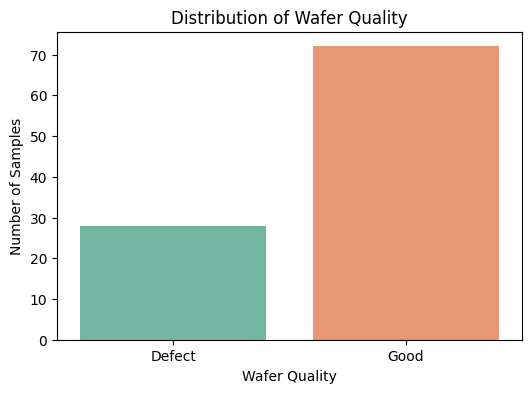

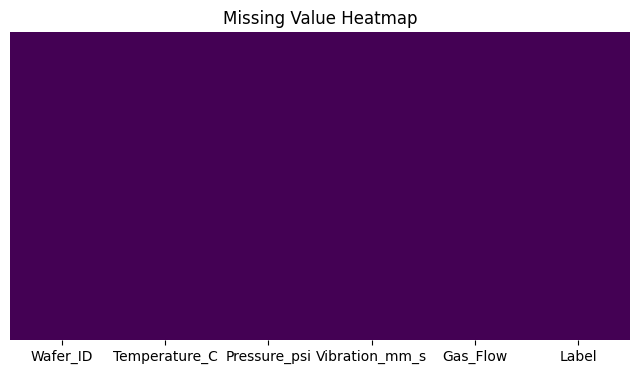

In [ ]:
# ==========================================
# STEP 1 : Loading and Understanding the Dataset
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ------------------------------------------
# Upload Dataset (Google Colab)
# ------------------------------------------
from google.colab import files

uploaded = files.upload()

# Ambil nama file yang di-upload secara otomatis
filename = list(uploaded.keys())[0]

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv(filename)

# ------------------------------------------
# Preview Dataset
# ------------------------------------------
print("========== FIRST FIVE ROWS ==========")
display(df.head())

print("\n========== LAST FIVE ROWS ==========")
display(df.tail())

# ------------------------------------------
# Dataset Information
# ------------------------------------------
print("\n========== DATASET INFORMATION ==========")
df.info()

# ------------------------------------------
# Dataset Shape
# ------------------------------------------
print("\n========== DATASET SHAPE ==========")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ------------------------------------------
# Column Names
# ------------------------------------------
print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

# ------------------------------------------
# Data Types
# ------------------------------------------
print("\n========== DATA TYPES ==========")
display(df.dtypes)

# ------------------------------------------
# Summary Statistics
# ------------------------------------------
print("\n========== SUMMARY STATISTICS ==========")
display(df.describe())

# ------------------------------------------
# Missing Values
# ------------------------------------------
print("\n========== MISSING VALUES ==========")
display(df.isnull().sum())

# ------------------------------------------
# Duplicate Records
# ------------------------------------------
print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# ------------------------------------------
# Label Distribution
# ------------------------------------------
print("\n========== LABEL DISTRIBUTION ==========")
display(df["Label"].value_counts())

# ------------------------------------------
# Label Percentage
# ------------------------------------------
print("\n========== LABEL PERCENTAGE ==========")
display(round(df["Label"].value_counts(normalize=True)*100,2))

# ==========================================
# Visualization
# ==========================================

# Label Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Label",
    palette="Set2"
)

plt.title("Distribution of Wafer Quality")
plt.xlabel("Wafer Quality")
plt.ylabel("Number of Samples")
plt.show()

# Missing Value Heatmap
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

2. Separating Features and Target Variables

In [ ]:
# ==========================================
# STEP 2 : Feature Selection and Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Select input features
X = df[['Temperature_C',
        'Pressure_psi',
        'Vibration_mm_s',
        'Gas_Flow']]

# Select target label
y = df['Label']

# Convert categorical labels into numerical values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Display feature matrix
print("Feature Matrix (X)")
display(X.head())

# Display encoded labels
print("\nEncoded Labels (y)")
print(y[:10])

# Display class mapping
print("\nLabel Encoding")
for index, label in enumerate(label_encoder.classes_):
    print(f"{label} → {index}")

Feature Matrix (X)


,Temperature_C,Pressure_psi,Vibration_mm_s,Gas_Flow
0,66.1,36.6,7.76,107.0
1,83.8,49.1,0.90,91.6
2,76.5,30.3,6.23,108.0
3,69.8,31.1,4.86,97.4
4,71.2,38.3,5.54,103.0



Encoded Labels (y)
[0 0 1 1 1 1 0 1 1 0]

Label Encoding
Defect → 0
Good → 1


3. Train-Test Split



In [ ]:
# ==========================================
# STEP 3 : Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                      # Input features
    y,                      # Target labels
    test_size=0.20,         # 20% testing data
    random_state=42,        # Ensures reproducible results
    stratify=y              # Maintain class distribution
)

# Display dataset sizes
print("=" * 50)
print("Training and Testing Dataset Summary")
print("=" * 50)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"\nTraining Features Shape : {X_train.shape}")
print(f"Testing Features Shape  : {X_test.shape}")

print(f"\nTraining Labels Shape   : {y_train.shape}")
print(f"Testing Labels Shape    : {y_test.shape}")

# Display the first few training samples
print("\nFirst Five Training Samples")
display(X_train.head())

print("\nFirst Five Training Labels")
print(y_train[:5])

Training and Testing Dataset Summary
Training Samples : 80
Testing Samples  : 20

Training Features Shape : (80, 4)
Testing Features Shape  : (20, 4)

Training Labels Shape   : (80,)
Testing Labels Shape    : (20,)

First Five Training Samples


,Temperature_C,Pressure_psi,Vibration_mm_s,Gas_Flow
85,82.1,44.9,2.80,98.2
58,69.7,48.5,3.50,107.8
57,70.8,45.8,2.24,108.4
4,71.2,38.3,5.54,103.0
64,76.8,32.6,3.88,102.2



First Five Training Labels
[0 1 1 1 1]


4. Training the Decision Tree Model

In [ ]:
# ==========================================
# STEP 4 : Train the Decision Tree Model
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    criterion="gini",      # Splitting criterion
    max_depth=4,           # Maximum tree depth
    random_state=42        # Reproducible results
)

# Train the model
decision_tree.fit(X_train, y_train)

print("=" * 50)
print("Decision Tree Model Training Completed")
print("=" * 50)

print(f"Tree Depth           : {decision_tree.get_depth()}")
print(f"Number of Leaf Nodes : {decision_tree.get_n_leaves()}")

print("\nThe Decision Tree model has successfully learned")
print("the relationship between IoT sensor data and")
print("wafer quality.")

Decision Tree Model Training Completed
Tree Depth           : 3
Number of Leaf Nodes : 4

The Decision Tree model has successfully learned
the relationship between IoT sensor data and
wafer quality.


5. Model Evaluation

In [ ]:
# ==========================================
# STEP 5 : Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Predict wafer quality using the testing dataset
y_pred = decision_tree.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("Decision Tree Model Evaluation")
print("=" * 50)

print(f"Model Accuracy : {accuracy:.2%}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Display Classification Report
print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Decision Tree Model Evaluation
Model Accuracy : 100.00%

Confusion Matrix
[[ 6  0]
 [ 0 14]]

Classification Report
              precision    recall  f1-score   support

      Defect       1.00      1.00      1.00         6
        Good       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



6. Decision Tree Visualization

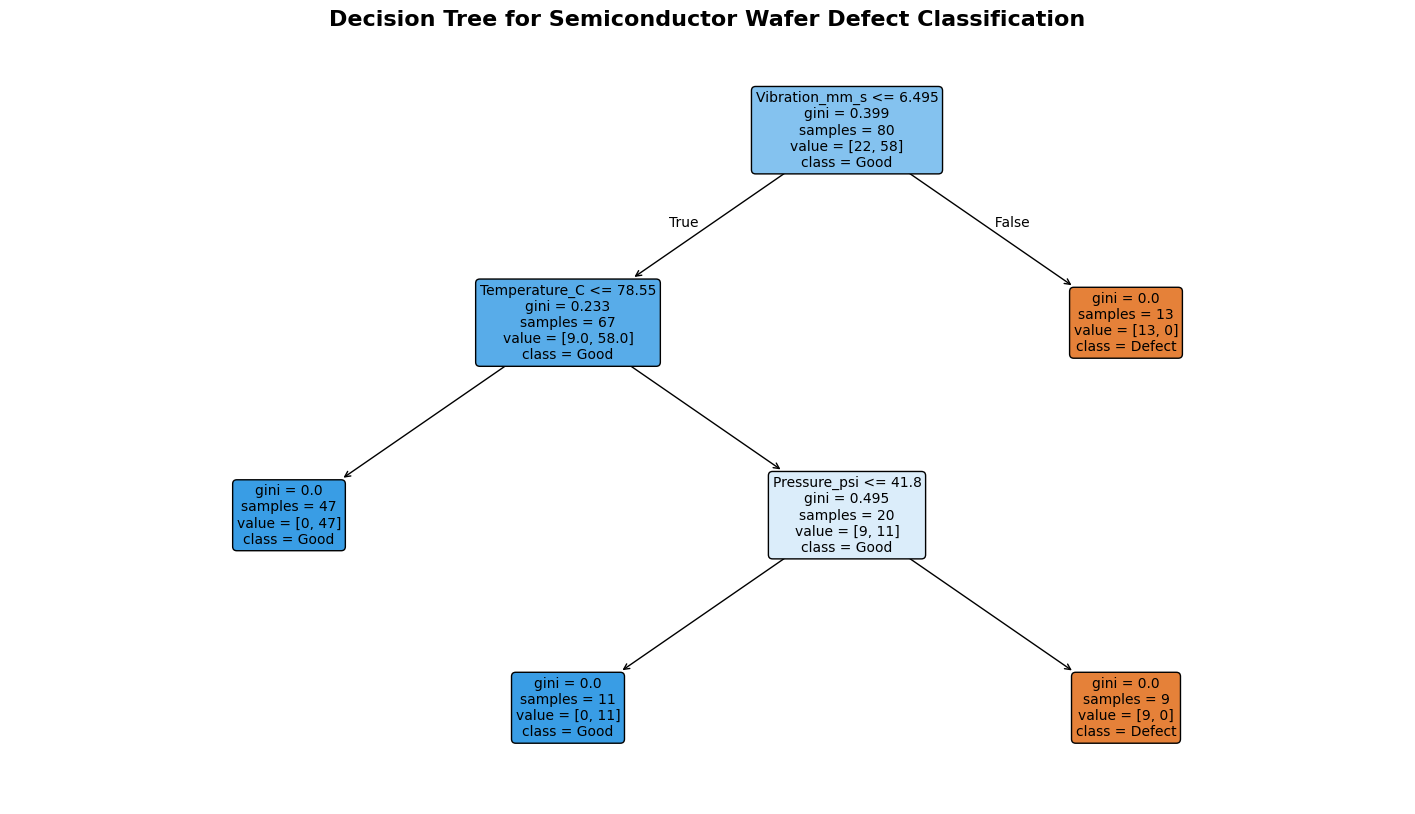

In [ ]:
# ==========================================
# STEP 6 : Decision Tree Visualization
# ==========================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a large figure for better readability
plt.figure(figsize=(18,10))

# Plot the trained Decision Tree
plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Decision Tree for Semiconductor Wafer Defect Classification",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [ ]:
7. Monte Carlo Simulation and Risk Analysis

In [ ]:
# ==========================================
# STEP 7 : Monte Carlo Simulation
# ==========================================

# Number of simulations
n_simulation = 10000

# Randomly generate sensor values
simulation_data = pd.DataFrame({
    "Temperature_C": np.random.uniform(
        df["Temperature_C"].min(),
        df["Temperature_C"].max(),
        n_simulation
    ),

    "Pressure_psi": np.random.uniform(
        df["Pressure_psi"].min(),
        df["Pressure_psi"].max(),
        n_simulation
    ),

    "Vibration_mm_s": np.random.uniform(
        df["Vibration_mm_s"].min(),
        df["Vibration_mm_s"].max(),
        n_simulation
    ),

    "Gas_Flow": np.random.uniform(
        df["Gas_Flow"].min(),
        df["Gas_Flow"].max(),
        n_simulation
    )
})

# Predict wafer quality
simulation_prediction = decision_tree.predict(simulation_data)

# Convert labels back to text
simulation_label = label_encoder.inverse_transform(simulation_prediction)

# Count prediction results
simulation_result = pd.Series(simulation_label).value_counts()

print("="*50)
print("Monte Carlo Simulation Result")
print("="*50)

print(simulation_result)

# Calculate probability
probability = simulation_result / n_simulation * 100

print("\nEstimated Probability (%)")
print(probability)

Monte Carlo Simulation Result
Good      6920
Defect    3080
Name: count, dtype: int64

Estimated Probability (%)
Good      69.2
Defect    30.8
Name: count, dtype: float64


8. Results Visualization and Final Conclusion

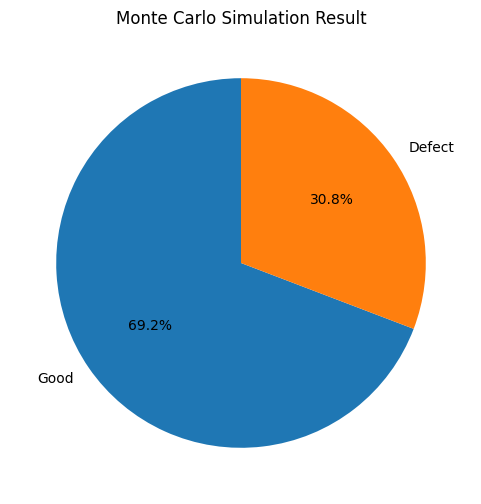

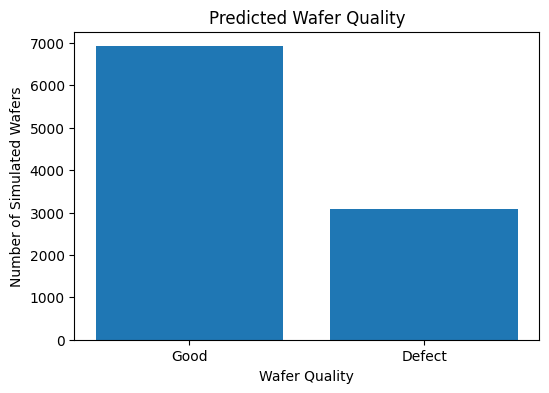

FINAL SUMMARY
Total Simulations : 10000
Good Wafers       : 6920
Defect Wafers     : 3080

Prediction Probability
Good    : 69.20%
Defect  : 30.80%


In [ ]:
# ==========================================
# STEP 8 : Results Visualization
# ==========================================

import matplotlib.pyplot as plt

# Pie Chart
plt.figure(figsize=(6,6))

plt.pie(
    simulation_result,
    labels=simulation_result.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Monte Carlo Simulation Result")

plt.show()


# Bar Chart
plt.figure(figsize=(6,4))

plt.bar(
    simulation_result.index,
    simulation_result.values
)

plt.title("Predicted Wafer Quality")
plt.xlabel("Wafer Quality")
plt.ylabel("Number of Simulated Wafers")

plt.show()

# Final Summary
print("="*50)
print("FINAL SUMMARY")
print("="*50)

print(f"Total Simulations : {n_simulation}")
print(f"Good Wafers       : {simulation_result['Good']}")
print(f"Defect Wafers     : {simulation_result['Defect']}")

print("\nPrediction Probability")

for label, value in probability.items():
    print(f"{label:8s}: {value:.2f}%")